# Credit Card Fraud Detection

This notebook follows the CS770 project proposal using two fraud-detection dataset sources:

- `creditcard.csv`
- `fraudTrain.csv` plus `fraudTest.csv`

The goal is binary classification: predict whether a credit card transaction is fraud or not fraud.

## Project Plan

The proposal says to compare Random Forest and Logistic Regression, account for class imbalance, use dimensionality reduction with PCA, and report accuracy, precision, recall, F1-score, confusion matrix, ROC curve, and AUC.

Because the two dataset sources have different schemas, this notebook trains and evaluates separate models for each source.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    PrecisionRecallDisplay,
    recall_score,
    RocCurveDisplay,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

sns.set_theme(style="whitegrid")

## 1. Load the Selected Datasets

In [2]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
DATA_CANDIDATES = [PROJECT_ROOT / "datasets", PROJECT_ROOT.parent / "datasets"]
DATA_DIR = next(
    (
        path
        for path in DATA_CANDIDATES
        if (path / "creditcard.csv").exists()
        and (path / "fraudTrain.csv").exists()
        and (path / "fraudTest.csv").exists()
    ),
    DATA_CANDIDATES[0],
)

CREDITCARD_PATH = DATA_DIR / "creditcard.csv"
TRAIN_PATH = DATA_DIR / "fraudTrain.csv"
TEST_PATH = DATA_DIR / "fraudTest.csv"

print("Creditcard data path:", CREDITCARD_PATH)
print("Training data path:", TRAIN_PATH)
print("Testing data path:", TEST_PATH)

creditcard_df = pd.read_csv(CREDITCARD_PATH)
train_df = pd.read_csv(TRAIN_PATH)
test_df = pd.read_csv(TEST_PATH)

print("creditcard shape:", creditcard_df.shape)
print("train shape:", train_df.shape)
print("test shape:", test_df.shape)
train_df.head()

Creditcard data path: c:\Users\cassh\Documents\ML\Final Project\Fraud-Detector\datasets\creditcard.csv
Training data path: c:\Users\cassh\Documents\ML\Final Project\Fraud-Detector\datasets\fraudTrain.csv
Testing data path: c:\Users\cassh\Documents\ML\Final Project\Fraud-Detector\datasets\fraudTest.csv
creditcard shape: (284807, 31)
train shape: (1296675, 23)
test shape: (555719, 23)


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [3]:
print("fraudTrain/fraudTest schema")
train_df.info()

print("\ncreditcard.csv schema")
creditcard_df.info()

fraudTrain/fraudTest schema
<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  l

## 2. Initial Analysis: Class Imbalance

Fraud detection datasets are usually highly imbalanced, meaning most transactions are not fraud. Because of that, accuracy alone can be misleading. Precision, recall, F1-score, PR-AUC, ROC-AUC, and the confusion matrix are more useful.

In [4]:
def show_class_balance(df, label="dataset", target_column="is_fraud"):
    counts = df[target_column].value_counts().sort_index()
    percents = df[target_column].value_counts(normalize=True).sort_index() * 100
    balance = pd.DataFrame({"count": counts, "percent": percents.round(4)})
    balance.index = ["not fraud", "fraud"]
    print(label)
    display(balance)
    return balance

train_balance = show_class_balance(train_df, "fraudTrain.csv", target_column="is_fraud")
test_balance = show_class_balance(test_df, "fraudTest.csv", target_column="is_fraud")
creditcard_balance = show_class_balance(creditcard_df, "creditcard.csv", target_column="Class")

fraudTrain.csv


,count,percent
not fraud,1289169,99.4211
fraud,7506,0.5789


fraudTest.csv


,count,percent
not fraud,553574,99.614
fraud,2145,0.386


creditcard.csv


,count,percent
not fraud,284315,99.8273
fraud,492,0.1727


C:\Users\cassh\AppData\Local\Temp\ipykernel_42476\2587016713.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not fraud", "fraud"])
C:\Users\cassh\AppData\Local\Temp\ipykernel_42476\2587016713.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not fraud", "fraud"])
C:\Users\cassh\AppData\Local\Temp\ipykernel_42476\2587016713.py:14: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["not fraud", "fraud"])


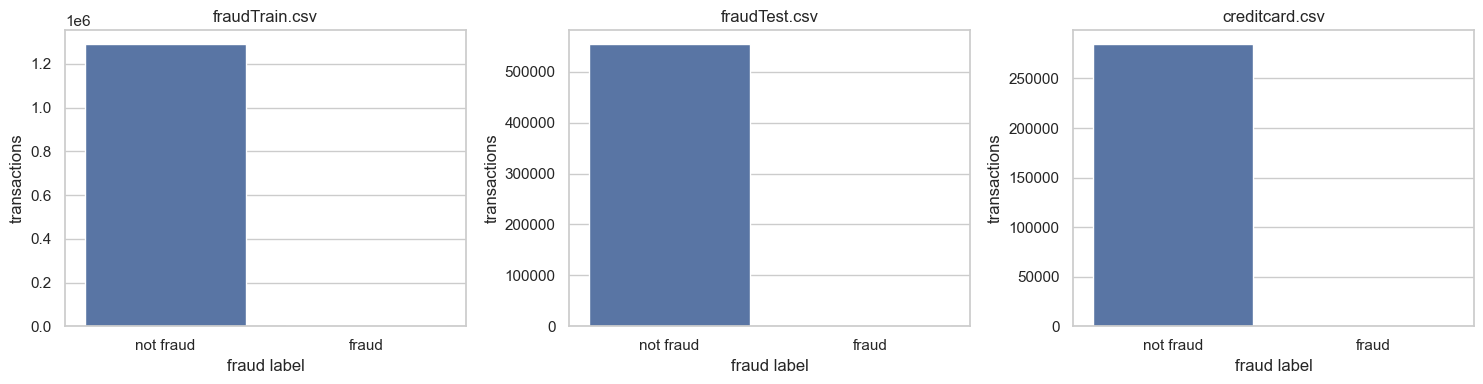

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

plot_specs = [
    (axes[0], train_df, "is_fraud", "fraudTrain.csv"),
    (axes[1], test_df, "is_fraud", "fraudTest.csv"),
    (axes[2], creditcard_df, "Class", "creditcard.csv"),
]

for ax, df, target, title in plot_specs:
    sns.countplot(data=df, x=target, ax=ax)
    ax.set_title(title)
    ax.set_xlabel("fraud label")
    ax.set_ylabel("transactions")
    ax.set_xticklabels(["not fraud", "fraud"])

plt.tight_layout()

## 3. Experiment 1: `fraudTrain.csv` and `fraudTest.csv`

The original transaction dataset contains identifiers and personally identifying text fields that are not good model inputs. This section keeps useful transaction features and creates date-based features like transaction hour, day of week, and cardholder age.

In [6]:
def add_time_features(df):
    df = df.copy()
    df["trans_date_trans_time"] = pd.to_datetime(df["trans_date_trans_time"], errors="coerce")
    df["dob"] = pd.to_datetime(df["dob"], errors="coerce")

    df["transaction_hour"] = df["trans_date_trans_time"].dt.hour
    df["transaction_dayofweek"] = df["trans_date_trans_time"].dt.dayofweek
    df["transaction_month"] = df["trans_date_trans_time"].dt.month
    df["age"] = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25

    return df

train_features_df = add_time_features(train_df)
test_features_df = add_time_features(test_df)

feature_columns = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "transaction_hour",
    "transaction_dayofweek",
    "transaction_month",
    "age",
    "category",
    "gender",
]

target_column = "is_fraud"

X_train_full = train_features_df[feature_columns]
y_train_full = train_features_df[target_column]
X_test_full = test_features_df[feature_columns]
y_test_full = test_features_df[target_column]

X_train_full.head()

,amt,lat,long,city_pop,merch_lat,merch_long,transaction_hour,transaction_dayofweek,transaction_month,age,category,gender
0,4.97,36.0788,-81.1781,3495,36.011293,-82.048315,0,1,1,30.814511,misc_net,F
1,107.23,48.8878,-118.2105,149,49.159047,-118.186462,0,1,1,40.531143,grocery_pos,F
2,220.11,42.1808,-112.2620,4154,43.150704,-112.154481,0,1,1,56.950034,entertainment,M
3,45.00,46.2306,-112.1138,1939,47.034331,-112.561071,0,1,1,51.969884,gas_transport,M
4,41.96,38.4207,-79.4629,99,38.674999,-78.632459,0,1,1,32.763860,misc_pos,M


In [7]:
USE_SAMPLE = False
TRAIN_SAMPLE_SIZE = 50_000
TEST_SAMPLE_SIZE = 25_000

def stratified_sample(X, y, sample_size, random_state=67):
    if (not USE_SAMPLE) or len(X) <= sample_size:
        return X.copy(), y.copy()

    _, X_sample, _, y_sample = train_test_split(
        X,
        y,
        test_size=sample_size,
        stratify=y,
        random_state=random_state,
    )
    return X_sample.reset_index(drop=True), y_sample.reset_index(drop=True)

X_train, y_train = stratified_sample(X_train_full, y_train_full, TRAIN_SAMPLE_SIZE)
X_test, y_test = stratified_sample(X_test_full, y_test_full, TEST_SAMPLE_SIZE)

print("training shape:", X_train.shape)
print("testing shape:", X_test.shape)
show_class_balance(pd.DataFrame({target_column: y_train}), "Model training set")
show_class_balance(pd.DataFrame({target_column: y_test}), "Model testing set")

training shape: (1296675, 12)
testing shape: (555719, 12)
Model training set


,count,percent
not fraud,1289169,99.4211
fraud,7506,0.5789


Model testing set


,count,percent
not fraud,553574,99.614
fraud,2145,0.386


,count,percent
not fraud,553574,99.614
fraud,2145,0.386


In [8]:
def build_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", drop="first", sparse=False)

numeric_features = [
    "amt",
    "lat",
    "long",
    "city_pop",
    "merch_lat",
    "merch_long",
    "transaction_hour",
    "transaction_dayofweek",
    "transaction_month",
    "age",
]

categorical_features = ["category", "gender"]


def build_preprocessor():
    return ColumnTransformer(
        transformers=[
            (
                "numeric",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]),
                numeric_features,
            ),
            (
                "categorical",
                Pipeline(steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", build_one_hot_encoder()),
                ]),
                categorical_features,
            ),
        ],
        remainder="drop",
        sparse_threshold=0,
    )


def build_pca():
    return PCA(n_components=0.95, random_state=67)

In [9]:
logistic_regression = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("pca", build_pca()),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=67,
        solver="lbfgs",
    )),
])

random_forest = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("pca", build_pca()),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=67,
    )),
])

In [10]:
models = {
    "Logistic Regression": logistic_regression,
    "Random Forest": random_forest,
}

fitted_models = {}
for model_name, model in models.items():
    print(f"Training {model_name}...")
    model.fit(X_train, y_train)
    fitted_models[model_name] = model
    print(f"Finished {model_name}")

Training Logistic Regression...
Finished Logistic Regression
Training Random Forest...
Finished Random Forest


In [11]:
for model_name, model in fitted_models.items():
    n_components = model.named_steps["pca"].n_components_
    explained_variance = model.named_steps["pca"].explained_variance_ratio_.sum()
    print(f"{model_name}: PCA kept {n_components} components explaining {explained_variance:.2%} variance")

Logistic Regression: PCA kept 12 components explaining 95.15% variance
Random Forest: PCA kept 12 components explaining 95.15% variance


In [12]:
def evaluate_model(model_name, model, X_test, y_test, threshold=0.50):
    y_prob = model.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= threshold).astype(int)

    metrics = {
        "model": model_name,
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_prob),
        "pr_auc": average_precision_score(y_test, y_prob),
    }

    print(f"\n{model_name}")
    print(classification_report(y_test, y_pred, target_names=["not fraud", "fraud"], zero_division=0))

    return metrics, y_pred, y_prob

results = []
predictions = {}

for model_name, model in fitted_models.items():
    metrics, y_pred, y_prob = evaluate_model(model_name, model, X_test, y_test)
    results.append(metrics)
    predictions[model_name] = {"y_pred": y_pred, "y_prob": y_prob}

results_df = pd.DataFrame(results).sort_values("pr_auc", ascending=False)
results_df


Logistic Regression
              precision    recall  f1-score   support

   not fraud       1.00      0.96      0.98    553574
       fraud       0.06      0.74      0.12      2145

    accuracy                           0.96    555719
   macro avg       0.53      0.85      0.55    555719
weighted avg       1.00      0.96      0.97    555719


Random Forest
              precision    recall  f1-score   support

   not fraud       1.00      1.00      1.00    553574
       fraud       0.91      0.65      0.76      2145

    accuracy                           1.00    555719
   macro avg       0.95      0.83      0.88    555719
weighted avg       1.00      1.00      1.00    555719



,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.5,0.998406,0.910633,0.650816,0.759108,0.967940,0.795411
0,Logistic Regression,0.5,0.956291,0.062956,0.743590,0.116084,0.872159,0.141235


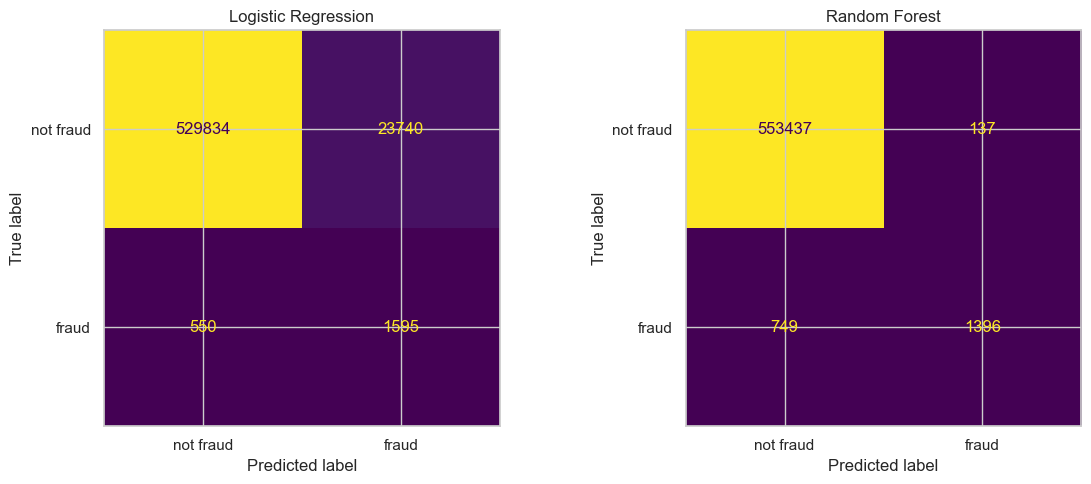

In [13]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(6 * len(fitted_models), 5))
if len(fitted_models) == 1:
    axes = [axes]

for ax, (model_name, preds) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not fraud", "fraud"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()

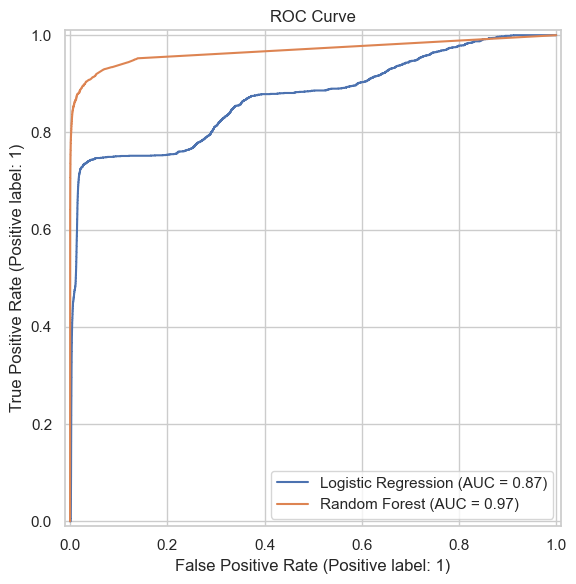

In [14]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, model in fitted_models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
ax.set_title("ROC Curve")
plt.tight_layout()

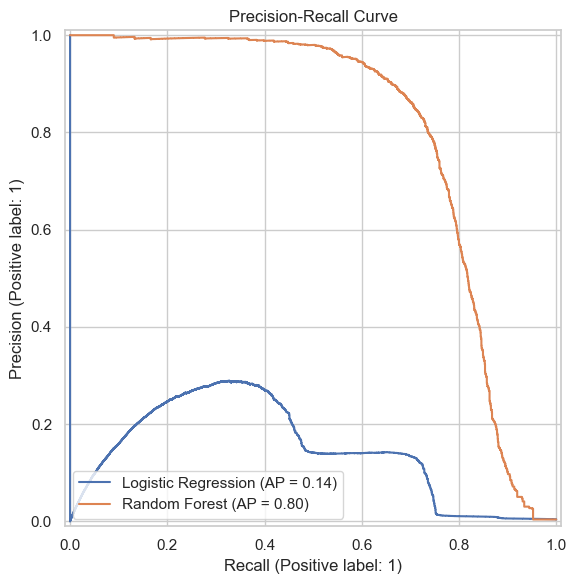

In [15]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, model in fitted_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax, name=model_name)
ax.set_title("Precision-Recall Curve")
plt.tight_layout()

## 8. Threshold Tuning

Fraud detection usually cares about catching fraud cases without creating too many false alarms. The default threshold of 0.50 is not always best, so this section compares thresholds using precision, recall, and F1-score.

In [16]:
threshold_rows = []
thresholds = np.arange(0.05, 0.96, 0.05)

for model_name, preds in predictions.items():
    y_prob = preds["y_prob"]
    for threshold in thresholds:
        y_pred_threshold = (y_prob >= threshold).astype(int)
        threshold_rows.append({
            "model": model_name,
            "threshold": threshold,
            "precision": precision_score(y_test, y_pred_threshold, zero_division=0),
            "recall": recall_score(y_test, y_pred_threshold, zero_division=0),
            "f1": f1_score(y_test, y_pred_threshold, zero_division=0),
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.sort_values(["model", "f1"], ascending=[True, False]).groupby("model").head(5)

,model,threshold,precision,recall,f1
18,Logistic Regression,0.95,0.239136,0.433566,0.308253
17,Logistic Regression,0.90,0.178897,0.467133,0.258714
13,Logistic Regression,0.70,0.139604,0.677389,0.231498
16,Logistic Regression,0.85,0.148808,0.482984,0.227517
14,Logistic Regression,0.75,0.140028,0.596737,0.226830
25,Random Forest,0.35,0.845218,0.712821,0.773394
26,Random Forest,0.40,0.869082,0.693240,0.771266
24,Random Forest,0.30,0.811020,0.734266,0.770736
27,Random Forest,0.45,0.893723,0.670396,0.766116
23,Random Forest,0.25,0.773186,0.750117,0.761477


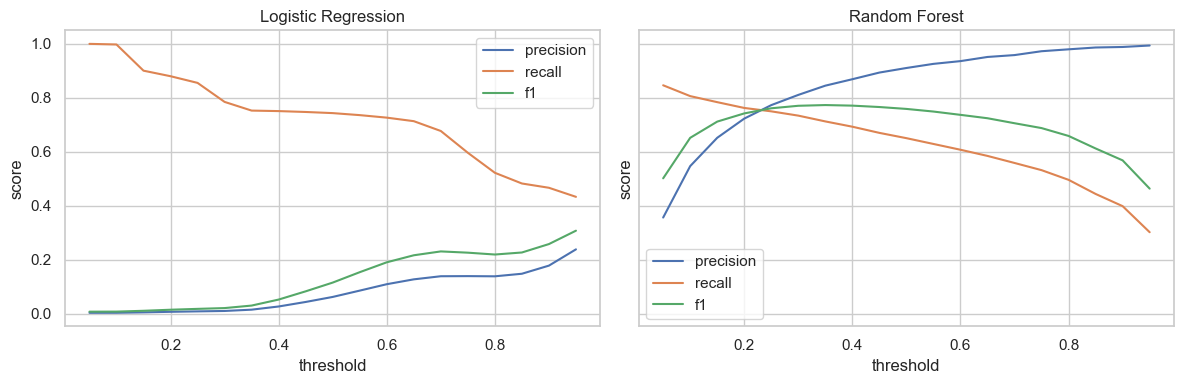

In [17]:
fig, axes = plt.subplots(1, len(fitted_models), figsize=(6 * len(fitted_models), 4), sharey=True)
if len(fitted_models) == 1:
    axes = [axes]

for ax, model_name in zip(axes, fitted_models.keys()):
    subset = threshold_df[threshold_df["model"] == model_name]
    ax.plot(subset["threshold"], subset["precision"], label="precision")
    ax.plot(subset["threshold"], subset["recall"], label="recall")
    ax.plot(subset["threshold"], subset["f1"], label="f1")
    ax.set_title(model_name)
    ax.set_xlabel("threshold")
    ax.set_ylabel("score")
    ax.legend()

plt.tight_layout()

In [18]:
rf_grid = Pipeline(steps=[
    ("preprocess", build_preprocessor()),
    ("pca", build_pca()),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        n_jobs=-1,
        random_state=67,
    )),
])
param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2, 5],
}
grid_search = GridSearchCV(
    estimator=rf_grid,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    verbose=1,
)
grid_search.fit(X_train, y_train)
print("best score:", grid_search.best_score_)
print("best params:", grid_search.best_params_)

Fitting 3 folds for each of 18 candidates, totalling 54 fits
best score: 0.978310437816107
best params: {'model__max_depth': 20, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}


## 11. Experiment 2: `creditcard.csv`

`creditcard.csv` has a different structure from the `fraudTrain.csv` and `fraudTest.csv` files. It already contains mostly numeric PCA-style features named `V1` through `V28`, plus `Time`, `Amount`, and the target column `Class`.

Because this file does not come with a separate test CSV, this section creates a stratified train/test split from `creditcard.csv`.

In [19]:
creditcard_target = "Class"
creditcard_feature_columns = [column for column in creditcard_df.columns if column != creditcard_target]

X_creditcard = creditcard_df[creditcard_feature_columns]
y_creditcard = creditcard_df[creditcard_target]

X_credit_train, X_credit_test, y_credit_train, y_credit_test = train_test_split(
    X_creditcard,
    y_creditcard,
    test_size=0.20,
    stratify=y_creditcard,
    random_state=67,
)

print("creditcard training shape:", X_credit_train.shape)
print("creditcard testing shape:", X_credit_test.shape)
show_class_balance(pd.DataFrame({creditcard_target: y_credit_train}), "creditcard training split", target_column=creditcard_target)
show_class_balance(pd.DataFrame({creditcard_target: y_credit_test}), "creditcard testing split", target_column=creditcard_target)

creditcard training shape: (227845, 30)
creditcard testing shape: (56962, 30)
creditcard training split


,count,percent
not fraud,227451,99.8271
fraud,394,0.1729


creditcard testing split


,count,percent
not fraud,56864,99.828
fraud,98,0.172


,count,percent
not fraud,56864,99.828
fraud,98,0.172


### Creditcard Preprocessing and Models

The dataset is already numeric, but `Amount` and `Time` are on different scales from the `V` features. The pipeline imputes missing values, scales all features, applies PCA, and trains the same two model types.

In [20]:
def build_creditcard_pipeline(model):
    return Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=0.95, random_state=67)),
        ("model", model),
    ])

creditcard_models = {
    "Creditcard Logistic Regression": build_creditcard_pipeline(LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=67,
        solver="lbfgs",
    )),
    "Creditcard Random Forest": build_creditcard_pipeline(RandomForestClassifier(
        class_weight="balanced",
        n_estimators=200,
        max_depth=None,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=67,
    )),
}

fitted_creditcard_models = {}
for model_name, model in creditcard_models.items():
    print(f"Training {model_name}...")
    model.fit(X_credit_train, y_credit_train)
    fitted_creditcard_models[model_name] = model
    print(f"Finished {model_name}")

Training Creditcard Logistic Regression...
Finished Creditcard Logistic Regression
Training Creditcard Random Forest...
Finished Creditcard Random Forest


In [21]:
creditcard_results = []
creditcard_predictions = {}

for model_name, model in fitted_creditcard_models.items():
    metrics, y_pred, y_prob = evaluate_model(model_name, model, X_credit_test, y_credit_test)
    creditcard_results.append(metrics)
    creditcard_predictions[model_name] = {"y_pred": y_pred, "y_prob": y_prob}

creditcard_results_df = pd.DataFrame(creditcard_results).sort_values("pr_auc", ascending=False)
creditcard_results_df


Creditcard Logistic Regression
              precision    recall  f1-score   support

   not fraud       1.00      0.98      0.99     56864
       fraud       0.07      0.85      0.12        98

    accuracy                           0.98     56962
   macro avg       0.53      0.91      0.56     56962
weighted avg       1.00      0.98      0.99     56962


Creditcard Random Forest
              precision    recall  f1-score   support

   not fraud       1.00      1.00      1.00     56864
       fraud       0.91      0.62      0.74        98

    accuracy                           1.00     56962
   macro avg       0.95      0.81      0.87     56962
weighted avg       1.00      1.00      1.00     56962



,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Creditcard Random Forest,0.5,0.999245,0.910448,0.622449,0.739394,0.939884,0.804267
0,Creditcard Logistic Regression,0.5,0.979583,0.067425,0.846939,0.124906,0.970590,0.682324


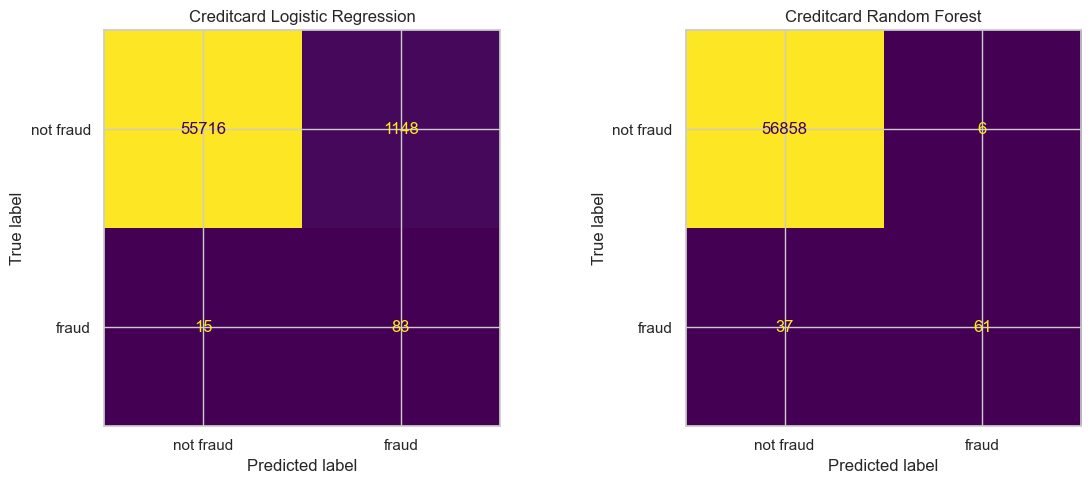

In [22]:
fig, axes = plt.subplots(1, len(fitted_creditcard_models), figsize=(6 * len(fitted_creditcard_models), 5))
if len(fitted_creditcard_models) == 1:
    axes = [axes]

for ax, (model_name, preds) in zip(axes, creditcard_predictions.items()):
    cm = confusion_matrix(y_credit_test, preds["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["not fraud", "fraud"])
    disp.plot(ax=ax, values_format="d", colorbar=False)
    ax.set_title(model_name)

plt.tight_layout()

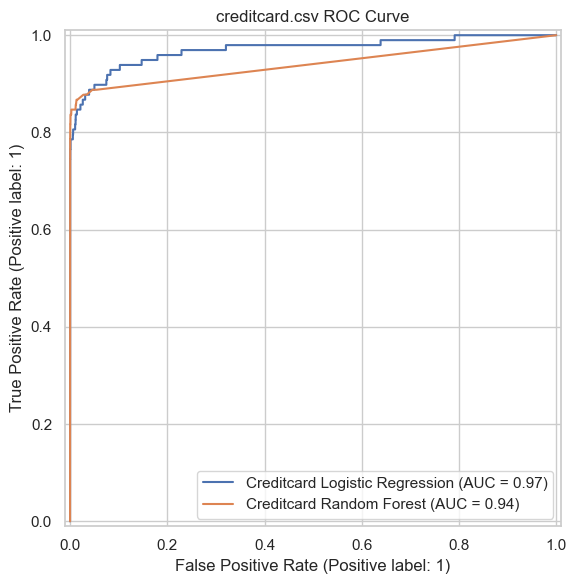

In [23]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, model in fitted_creditcard_models.items():
    RocCurveDisplay.from_estimator(model, X_credit_test, y_credit_test, ax=ax, name=model_name)
ax.set_title("creditcard.csv ROC Curve")
plt.tight_layout()

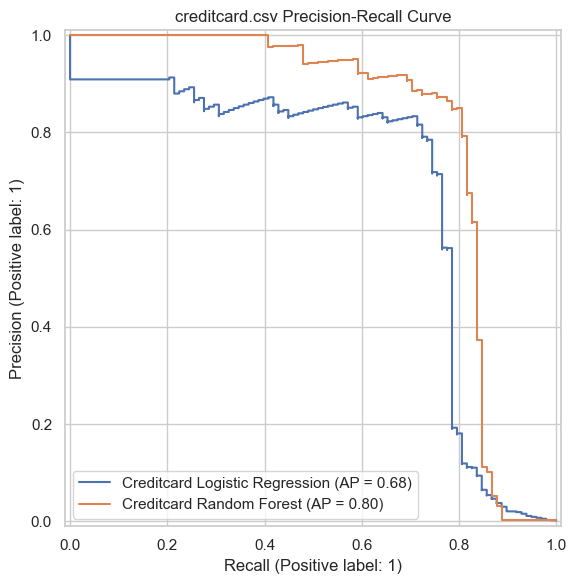

In [24]:
fig, ax = plt.subplots(figsize=(7, 6))
for model_name, model in fitted_creditcard_models.items():
    PrecisionRecallDisplay.from_estimator(model, X_credit_test, y_credit_test, ax=ax, name=model_name)
ax.set_title("creditcard.csv Precision-Recall Curve")
plt.tight_layout()

## 12. Compare Both Dataset Sources

Use the transaction results table and the `creditcard.csv` results table separately in the report. The schemas are different, so their scores should not be interpreted as one shared train/test experiment. They are two related fraud-detection experiments using the same modeling approach.

In [25]:
print("fraudTrain/fraudTest results")
display(results_df)

print("creditcard.csv results")
display(creditcard_results_df)

fraudTrain/fraudTest results


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Random Forest,0.5,0.998406,0.910633,0.650816,0.759108,0.967940,0.795411
0,Logistic Regression,0.5,0.956291,0.062956,0.743590,0.116084,0.872159,0.141235


creditcard.csv results


,model,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc
1,Creditcard Random Forest,0.5,0.999245,0.910448,0.622449,0.739394,0.939884,0.804267
0,Creditcard Logistic Regression,0.5,0.979583,0.067425,0.846939,0.124906,0.970590,0.682324
